# CVLAB Summer Project — Stage 3: FM Before a Linear Classifier

**DTD · FGVC-Aircraft | frozen encoders | FM → frozen Stage-1 probe**

Stage 3 inserts an FM transformation **before** the pretrained linear classifier:

$$z \;\xrightarrow{\;\mathrm{FM},\;T\;\text{Euler steps}\;}\; \hat{z} \;\xrightarrow{\;\text{frozen linear classifier}\;}\; s$$

The linear classifier is trained first, **exactly as in Stage 1**, then frozen; the FM is initialized close to identity so that, before Stage-3 training, the complete system behaves like the original linear probe. The question: **can FM transform the frozen encoder features into a representation the existing classifier separates better?** Specification: `_docs/stage_3.pdf`; every decision it leaves open was fixed *before* the first training run in ADR 0008 (`docs/adr/0008-stage3-design-decisions.md`), which itself survived three rounds of an external methodological review (R1–R28, all resolved) plus a cv-expert pre-run review.

Three heads are compared per dataset, exactly as the spec's Main Comparison requires:

1. **Pinned Stage-1 linear probe** — the baseline, and literally the frozen classifier inside the pipeline;
2. **Strategy 1 — end-to-end rolled-out classification training**: backpropagate CE through the complete rollout, updating only the FM; with a relative displacement regularizer $\lambda\,\overline{\lVert\hat{z}-z\rVert^2/\lVert z\rVert^2}$ (the spec explicitly invites such regularization), $\lambda$ selected on validation, and the pre-registered $\lambda = 0$ variant always reported;
3. **Strategy 2 — classifier-guided targets + standard FM training**: the frozen classifier's feature-space CE gradient constructs a nearby improved target $\hat{z}'$, and the FM is trained with the *standard* velocity-regression loss toward it — **no CE gradient ever reaches the FM**.

**Scope (per the spec):** one encoder per dataset — DTD → ResNet-18, FGVC-Aircraft → DINOv2 (the Stage-1 validation-selected encoders); one training-set size K = 10 (the spec's suggested default); one fixed T = 4 throughout. Three runs per setting (subset seeds {0, 1, 2}, probe-init and FM-init fixed at 0, as in Stage 1) so every Δ is **paired per seed** against the exact pinned probe of that seed.

## 1 · Environment, configuration, and the pre-registered protocol

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.utils import load_config

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)

with open(REPO / "results" / "runtime_summary.json") as f:
    print("Runtime:", json.dumps(json.load(f), indent=2))

cfg = load_config()
s3 = cfg["stage3"]
print("\nSettings:", s3["settings"], "| K =", s3["k_shot"], "| T =", s3["T"],
      "| feature space:", s3["feature_space"])
print("Training policy:", json.dumps(s3["training"], indent=2))
print("S1 lambda grid:", s3["strategy1"]["lambda_grid"],
      "| S2 grid: beta", s3["strategy2"]["beta_grid"], "x m", s3["strategy2"]["m_grid"],
      "| trust region alpha =", s3["strategy2"]["alpha_trust_region"])

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Settings: [['dtd', 'resnet18'], ['fgvc_aircraft', 'dinov2_vits14']] | K = 10 | T = 4 | feature space: raw
Training policy: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "epochs": 200,
  "checkpoint_selection": "highest_validation_accuracy",
  "fallbacks": [
    "grad_clip_1.0",
    "lr_3e-4",
    "input_standardization"
  ]
}
S1 lambda grid: [0, 1, 10, 100] | S2 grid: beta [0.25, 0.5, 1.0] x m [1, 3] | trust region alpha = 0.1


**Provenance of every choice.** The FM operates in **raw feature space** — the probe was trained on raw features ($s = Wz + b$, norms ≈ 10–40), so normalizing on entry would break the required identity-at-initialization (note the deliberate contrast with Stage 2, where the downstream classifier was cosine-based and the FM therefore lived on the unit sphere: *the FM operates in the space its downstream classifier acts in*). The velocity network and Euler procedure are the Stage-2 design, as the spec instructs (MLP $d{+}1 \to 512 \to 512 \to d$, SiLU, scalar $t$ concatenated; $\hat{z}_{k+1} = \hat{z}_k + \frac{1}{T}v_\theta(\hat{z}_k, k/T)$). **Identity initialization is exact**: the final velocity layer (weight *and* bias) starts at zero, so $\hat{z} = z$ bit-for-bit — asserted, not assumed (§2).

**Training policy (uniform for both strategies, fixed a priori):** AdamW, lr $10^{-3}$, weight decay $10^{-4}$, batch 64, exactly 200 epochs with the **best-validation-accuracy checkpoint** retained (ties → lowest validation CE → earliest epoch). Validation-based selection is deliberate and symmetric: the baseline probe itself was selected the same way in Stage 1, and both strategies expose the identical full-pipeline validation curve. Failure policy (objective trigger — NaN/Inf loss only): restart with the next pre-registered fallback (cumulative ladder: grad-clip 1.0 → lr 3e-4 → internal input standardization, which preserves the exact identity); finite late deterioration is absorbed by checkpointing; exhausted ladder ⇒ run marked failed. **Hyperparameters were selected per dataset on seed-0 validation only**; winners applied unchanged to seeds 1–2; the **test split stayed sealed** during all training and selection, and was evaluated in **one final pass per pre-registered phase** (the mandatory grid; then the optional extension), each over its already-locked checkpoints. Disclosed: seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate.

## 2 · The two training strategies, and the guards that anchor the comparison

**Strategy 1 — end-to-end rolled-out classification training.** For each training feature $z$, run the complete $T$-step rollout to $\hat{z}$, pass it through the frozen classifier, and minimize

$$\mathcal{L}_{\mathrm{cls}} = \mathrm{CE}(W\hat{z} + b,\, y) \;+\; \lambda\,\mathrm{mean}_i\,\frac{\lVert\hat{z}_i - z_i\rVert^2}{\lVert z_i\rVert^2 + \varepsilon},$$

backpropagating through the full rollout and updating **only** the FM parameters. The relative displacement penalty (the spec's suggested regularization, made scale-free) discourages unnecessarily large changes; $\lambda$ is chosen on validation from {0, 1, 10, 100} and the $\lambda = 0$ variant is always test-reported alongside the winner (pre-registered pair).

**Strategy 2 — classifier-guided targets and standard FM training.** Per epoch, in two phases. *Phase 1 (targets, snapshot):* run every training feature through the current FM to $\hat{z}$; project onto the trust region, $u_0 = \Pi_{B(z,\rho)}(\hat{z})$ with $\rho = 0.1\lVert z\rVert$; take $m$ normalized CE-gradient steps of size $\eta = \beta\rho$, re-projecting after every step,

$$u_{j+1} = \Pi_{B(z,\rho)}\!\left(u_j - \eta\,\frac{\nabla_{u_j}\mathrm{CE}}{\lVert\nabla_{u_j}\mathrm{CE}\rVert + \varepsilon}\right);$$

the target $\hat{z}'$ is the **lowest-CE iterate** among the projected $\{u_0,\dots,u_m\}$ (monotone acceptance), detached, cached for all samples. *Phase 2 (FM update):* one epoch of **standard FM regression** against the fixed cache — $t \sim U(0,1)$, $z_t = (1-t)z + t\hat{z}'$, loss $\lVert v_\theta(z_t, t) - (\hat{z}' - z)\rVert^2$. All target quantities are per-sample; **no CE gradient ever reaches the FM** — that separation is the scientific contrast with Strategy 1. Grid: $\beta \in \{0.25, 0.5, 1\} \times m \in \{1, 3\}$ on validation. The source-centered trust region (not one centered at $\hat{z}$) is what prevents cumulative target drift across epochs — without it, repeated recomputation could manufacture arbitrarily classifier-friendly features.

**Two guards, train/validation data only (the test set stayed sealed):**

1. **Exact identity at initialization** — transported features **bit-exact equal** to the inputs, logits equal, predictions identical between the pipeline and the direct probe. Stronger than accuracy equality (two systems can share accuracy while disagreeing on many predictions). The cell below re-executes it.
2. **Pinned-probe reproduction** — the probe is retrained with the identical Stage-1 recipe per (dataset, subset seed), its **validation** accuracy audited against `runs.csv` (|diff| < 0.25 pts; the run log shows 0.000 pts and identical best epochs on all six probes), and the weights pinned so every method receives the same frozen classifier. Δ is computed against **this exact pinned probe** — `runs.csv` serves as a reproduction audit only; the cell below displays the recorded accuracies reproducing the published values within $10^{-12}$ (test compared post-hoc at the final pass).

In [2]:
import torch

from src.stage3 import Stage3FM, identity_guard, load_pinned_probe
from src.embeddings import load_features

mdir = REPO / "results" / "artifacts" / "stage3_models"
k = f"{cfg['stage3']['k_shot']}shot"
print("Exact-identity guard (re-executed live, validation data only):")
for ds, enc in cfg["stage3"]["settings"]:
    probe = load_pinned_probe(mdir / f"probe_{ds}_{enc}_{k}_seed0.pt")
    fval = load_features(ds, "val", enc)
    fm0 = Stage3FM(probe, fval["dim"], seed=cfg["stage3"]["fm_init_seed"])
    identity_guard(fm0, fval["features"][:256])
    print(f"  [OK] {ds} / {enc}: transported features bit-exact, logits and "
          f"predictions identical to the direct probe")

Exact-identity guard (re-executed live, validation data only):


  [OK] dtd / resnet18: transported features bit-exact, logits and predictions identical to the direct probe
  [OK] fgvc_aircraft / dinov2_vits14: transported features bit-exact, logits and predictions identical to the direct probe


In [3]:
# Probe-reproduction audit, displayed from the artifacts of record: the pinned
# probes' validation and test accuracies against the published Stage-1 values.
r1 = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for seed in cfg["stage3"]["subset_seeds"]:
        pin = r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                 & (r3["head"] == "pinned_probe") & (r3["seed"] == seed)].iloc[0]
        ref = r1[(r1["dataset"] == ds) & (r1["encoder"] == enc)
                 & (r1["head"] == "linear_probe") & (r1["k_shot"] == k)
                 & (r1["seed"] == seed)].iloc[0]
        rows.append({"dataset": ds, "seed": seed,
                     "pinned val (%)": round(100 * pin["val_acc"], 4),
                     "Stage-1 val (%)": round(100 * ref["val_acc"], 4),
                     "pinned test (%)": round(100 * pin["test_acc"], 4),
                     "Stage-1 test (%)": round(100 * ref["test_acc"], 4),
                     "within 1e-12": bool(np.isclose(pin["val_acc"], ref["val_acc"],
                                                     rtol=0, atol=1e-12)
                                          and np.isclose(pin["test_acc"],
                                                         ref["test_acc"],
                                                         rtol=0, atol=1e-12))})
audit = pd.DataFrame(rows)
assert audit["within 1e-12"].all()
print("Pinned-probe reproduction audit — recorded validation and test accuracies "
      "reproduce the published Stage-1 values within 1e-12 on all six probes "
      "(equal accuracies do not by themselves prove identical weights; the "
      "feature-level bit-exactness claim belongs to the identity guard above):")
display(audit)

Pinned-probe reproduction audit — recorded validation and test accuracies reproduce the published Stage-1 values within 1e-12 on all six probes (equal accuracies do not by themselves prove identical weights; the feature-level bit-exactness claim belongs to the identity guard above):


,dataset,seed,pinned val (%),Stage-1 val (%),pinned test (%),Stage-1 test (%),within 1e-12
0,dtd,0,50.74,50.74,53.99,53.99,True
1,dtd,1,54.10,54.10,54.47,54.47,True
2,dtd,2,51.33,51.33,54.47,54.47,True
3,fgvc_aircraft,0,52.51,52.51,52.12,52.12,True
4,fgvc_aircraft,1,51.43,51.43,51.52,51.52,True
5,fgvc_aircraft,2,49.35,49.35,50.26,50.26,True


## 3 · Classification results

Every number is generated programmatically from `results/metrics/` and re-derived by the repro check; raw per-run accuracies in `results/metrics/raw/stage3_*.npy`, the per-run table in `runs_stage3.csv`. Δ is **paired per seed** against the exact pinned probe of that seed.

### 3.1 Main comparison (the spec's required table)

In [4]:
display(Markdown((REPO / "results" / "metrics" / "stage3_main_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Head | Top-1 (%) | Δ vs pinned probe (pts, paired) |
|---|---|---|---|
| DTD / ResNet-18 | Pinned Stage-1 probe (baseline) | 54.31 ± 0.28 | — |
| DTD / ResNet-18 | Strategy 1 — rolled-out CE training (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 (1/3 seeds > 0) |
| DTD / ResNet-18 | Strategy 2 — classifier-guided targets (β = 0.25, m = 1) | 54.47 ± 0.70 | +0.16 ± 0.45 (2/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Pinned Stage-1 probe (baseline) | 51.30 ± 0.95 | — |
| FGVC-Aircraft / DINOv2 | Strategy 1 — rolled-out CE training (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 (3/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Strategy 2 — classifier-guided targets (β = 0.5, m = 3) | 53.80 ± 0.95 | +2.50 ± 0.50 (3/3 seeds > 0) |

Top-1 accuracy (%) on the complete official test split, K = 10, T = 4; mean ± sample std over the 3 subset seeds. Δ is **paired per seed** against the exact pinned probe of that seed — the identical frozen classifier inside the pipeline (the pipeline at initialization equals it exactly, by the zero-velocity init). Hyperparameters (λ; β, m) were selected per dataset on **seed-0 validation** only; seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate. n = 3 — no significance claims.

### 3.2 Strategy 1 — with vs without the displacement regularizer (pre-registered pair)

In [5]:
display(Markdown((REPO / "results" / "metrics" / "stage3_lambda_ablation_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | validation-selected λ (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 |
| DTD / ResNet-18 | λ = 0 | 53.51 ± 1.25 | -0.80 ± 0.98 |
| FGVC-Aircraft / DINOv2 | validation-selected λ (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 |
| FGVC-Aircraft / DINOv2 | λ = 0 | 51.80 ± 0.88 | +0.50 ± 0.95 |

Pre-registered pair: the validation winner AND λ = 0 both receive a test read-out, so the with/without-regularization comparison involves no post-hoc choice.

### 3.3 Selection transparency — the full seed-0 validation sweep

Everything the winners were chosen from, so the selection involves no undisclosed freedom. Test was untouched during selection. One panel per (dataset, strategy) — the two strategies are never mixed on one axis: markers are the seed-0 **validation** top-1 of every swept configuration, ★ the validation-selected winner (highest validation accuracy; ties → lowest validation CE → grid order), "ep" the checkpoint epoch of that run, and the dashed line the pinned probe's seed-0 validation accuracy — the pipeline at its identity initialization. Every run completed at fallback level 0 (the default recipe). The generated table of record behind the figure is `results/metrics/stage3_sweep_table.md`.

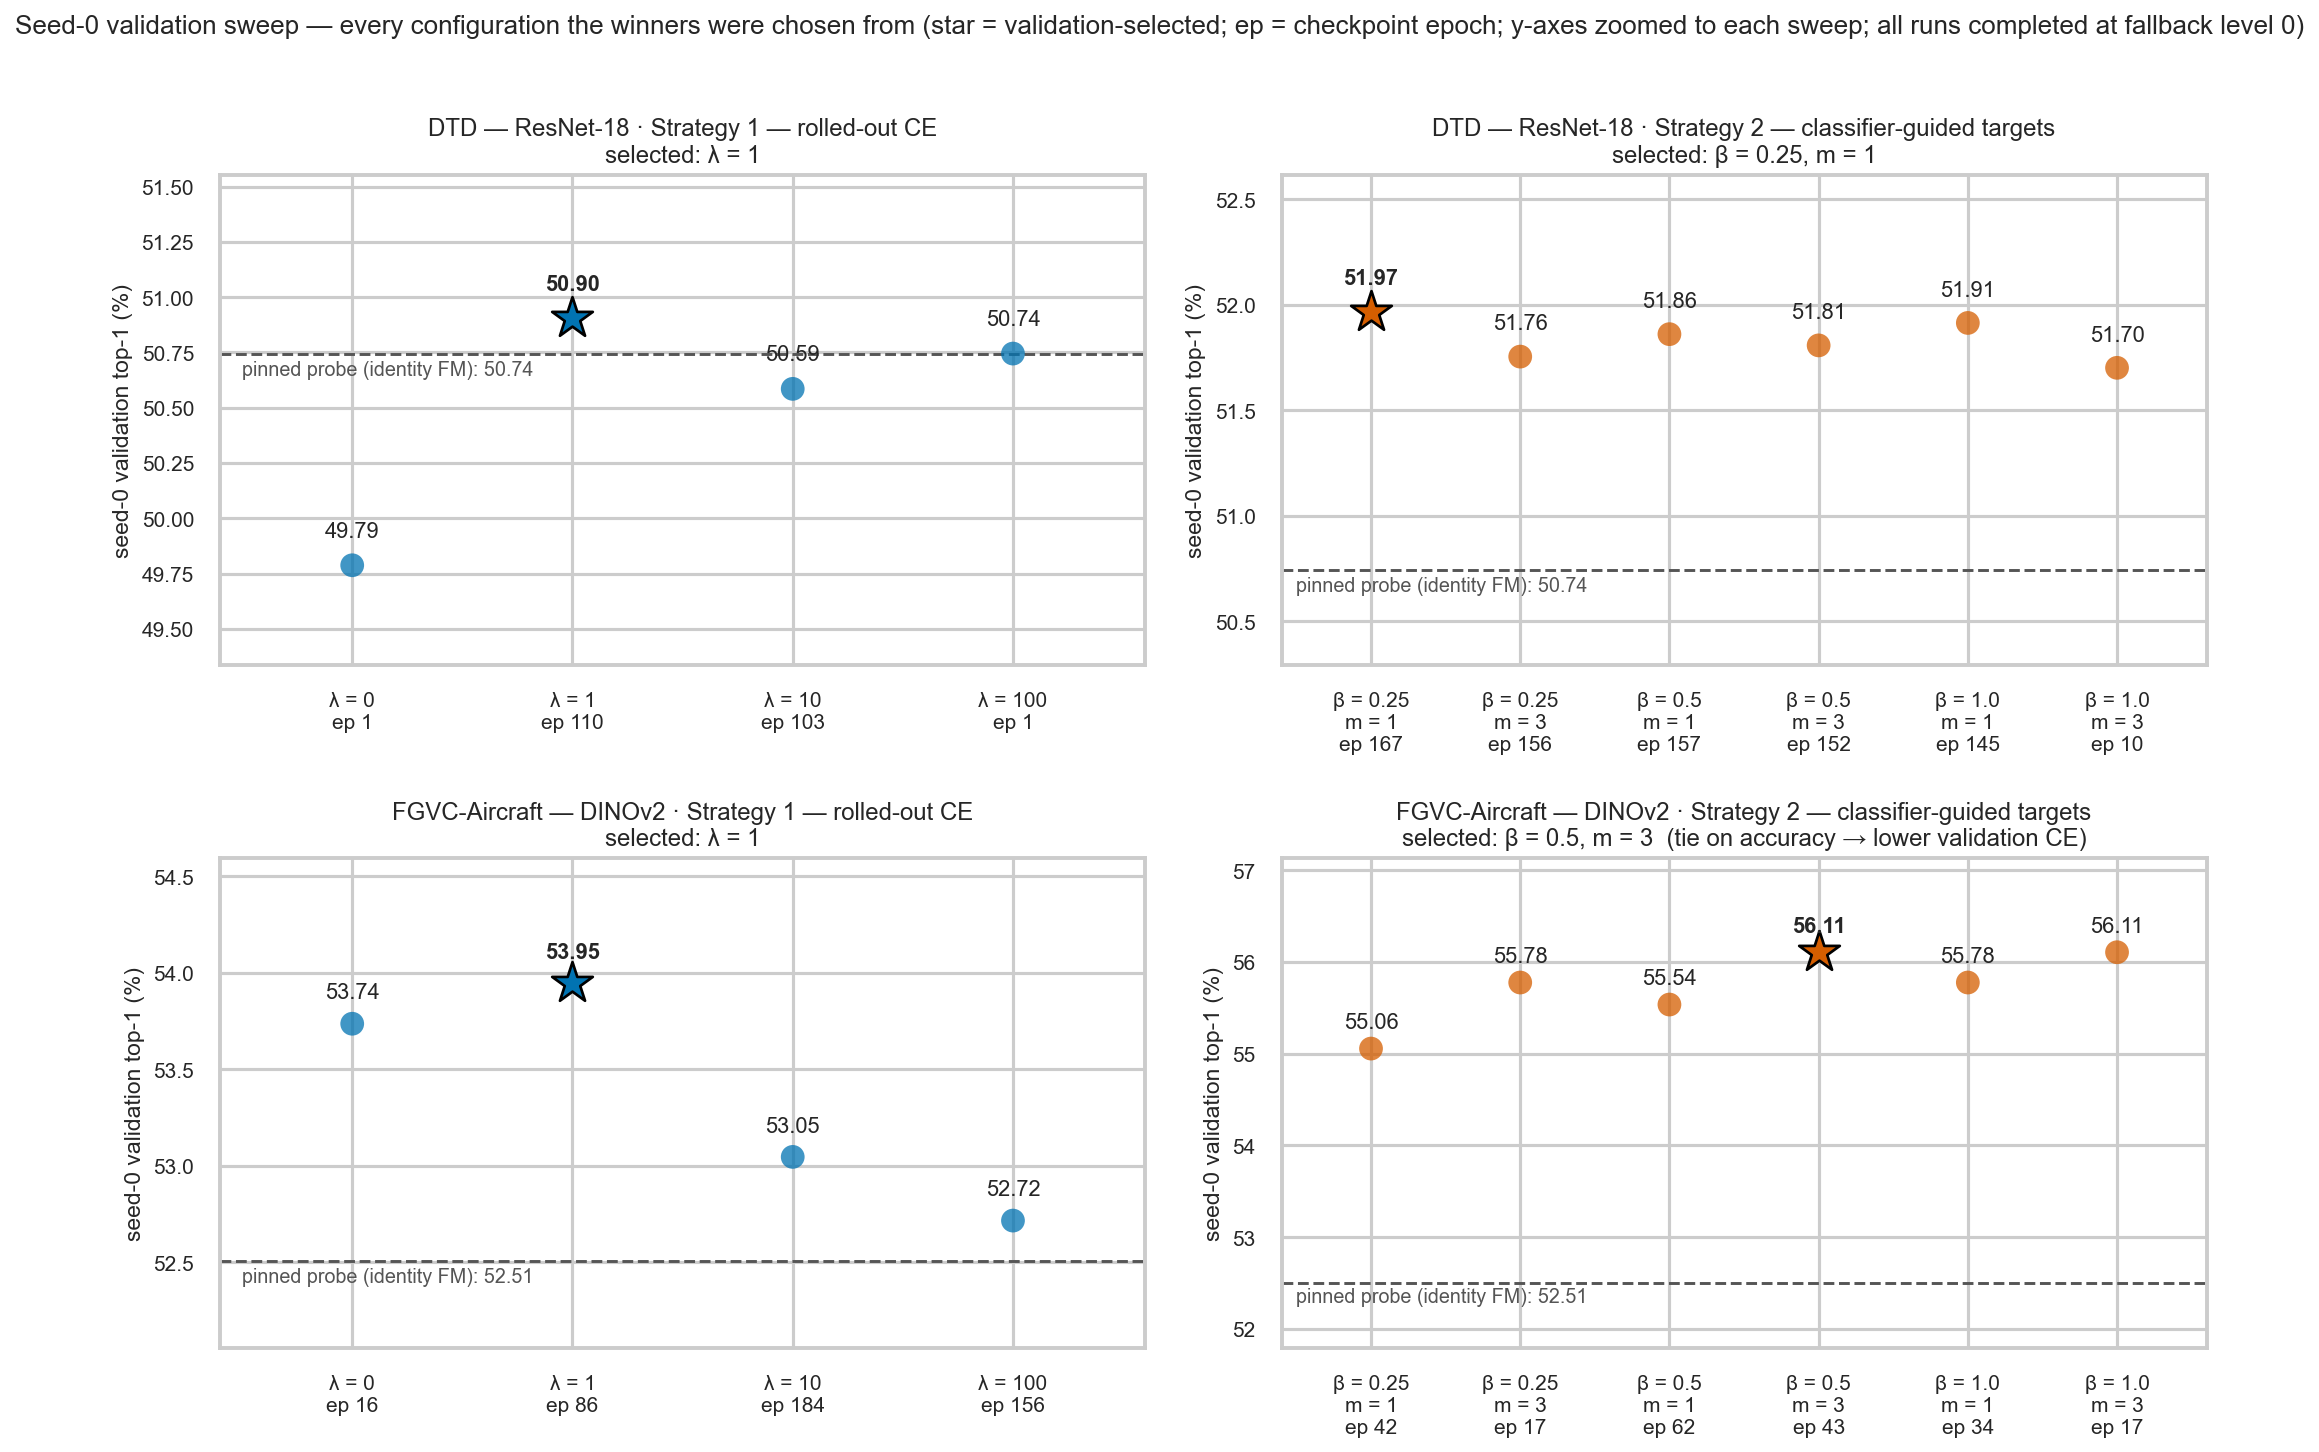

In [6]:
display(Image(str(REPO / "results" / "figures" / "stage3_sweep.png"), width=1150))

In [7]:
from src.visualize import dataset_label, encoder_label

HEAD_SHOW = {"fm_s1": "Strategy 1", "fm_s1_lambda0": "Strategy 1, λ=0",
             "fm_s2": "Strategy 2"}
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
ok = r3[r3["status"] == "ok"]
print("Per-seed paired deltas (percentage points), the quantity every claim rests on:")
t = (ok[ok["head"] != "pinned_probe"]
     .assign(setting=lambda d: d["dataset"].map(dataset_label) + " / "
             + d["encoder"].map(lambda e: encoder_label(e, short=True)),
             method=lambda d: d["head"].map(HEAD_SHOW),
             delta_pts=lambda d: (100 * d["delta_acc"]).round(2))
     .pivot_table(index=["setting", "method"], columns="seed", values="delta_pts"))
display(t)

Per-seed paired deltas (percentage points), the quantity every claim rests on:


seed                                       0     1     2
setting                method                           
DTD / ResNet-18        Strategy 1      -1.17 -1.01  0.11
                       Strategy 1, λ=0 -1.91 -0.37 -0.11
                       Strategy 2      -0.27  0.11  0.64
FGVC-Aircraft / DINOv2 Strategy 1       1.14  0.72  0.78
                       Strategy 1, λ=0  0.63 -0.51  1.38
                       Strategy 2       2.76  1.92  2.82

## 4 · Training behaviour

**Comparable end-to-end metrics on shared axes** (the spec's required training + validation curves, both methods): the full-pipeline cross-entropy and top-1 accuracy of $z \to \mathrm{FM} \to$ frozen probe, on train and validation, every epoch. Representative run: subset seed 0 (the validation-selected winners). Dashed = train, solid = validation; blue = Strategy 1, orange = Strategy 2.

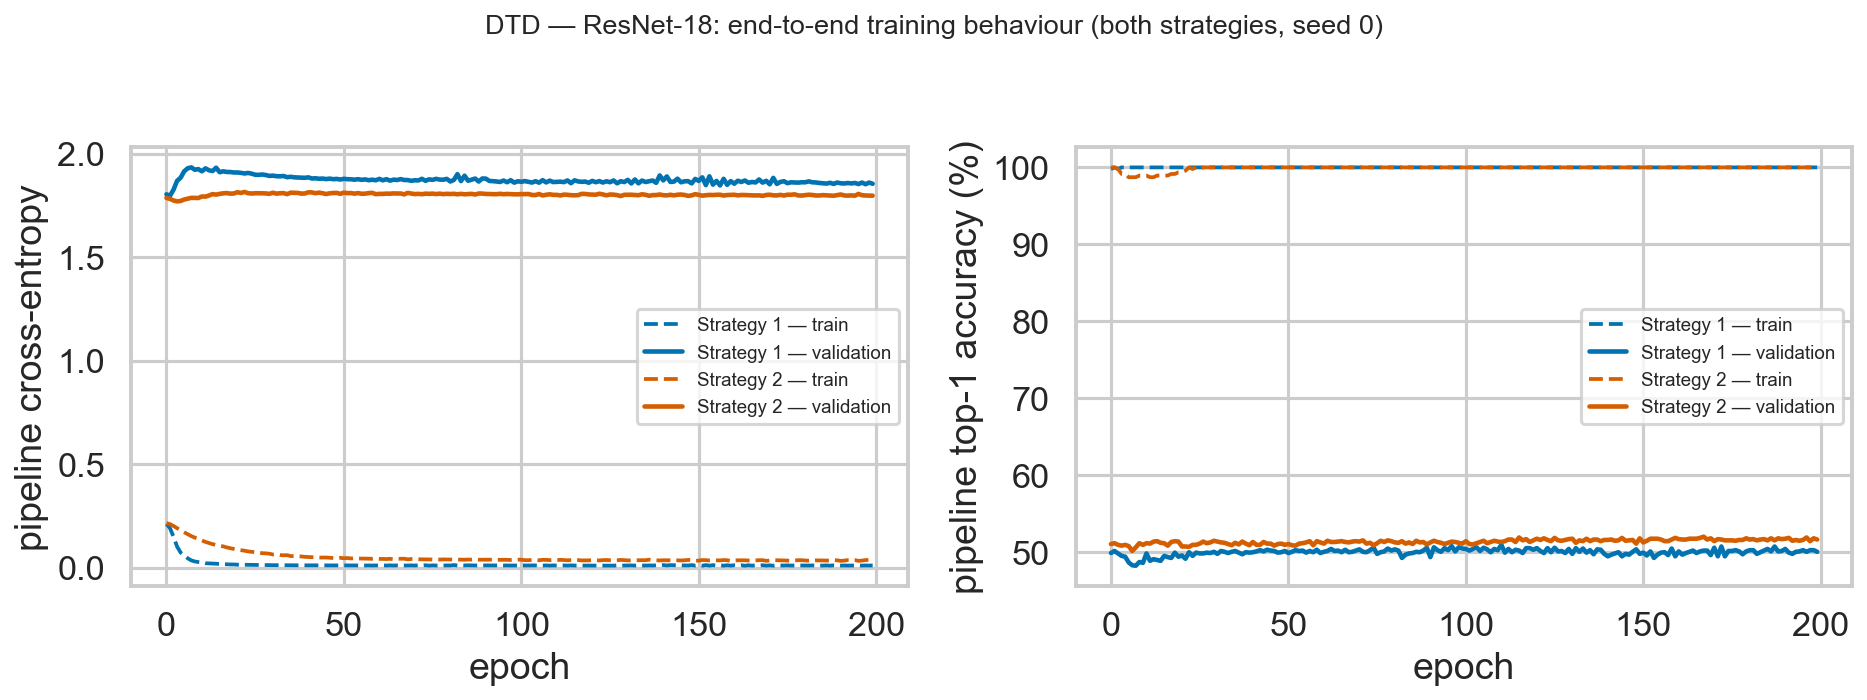

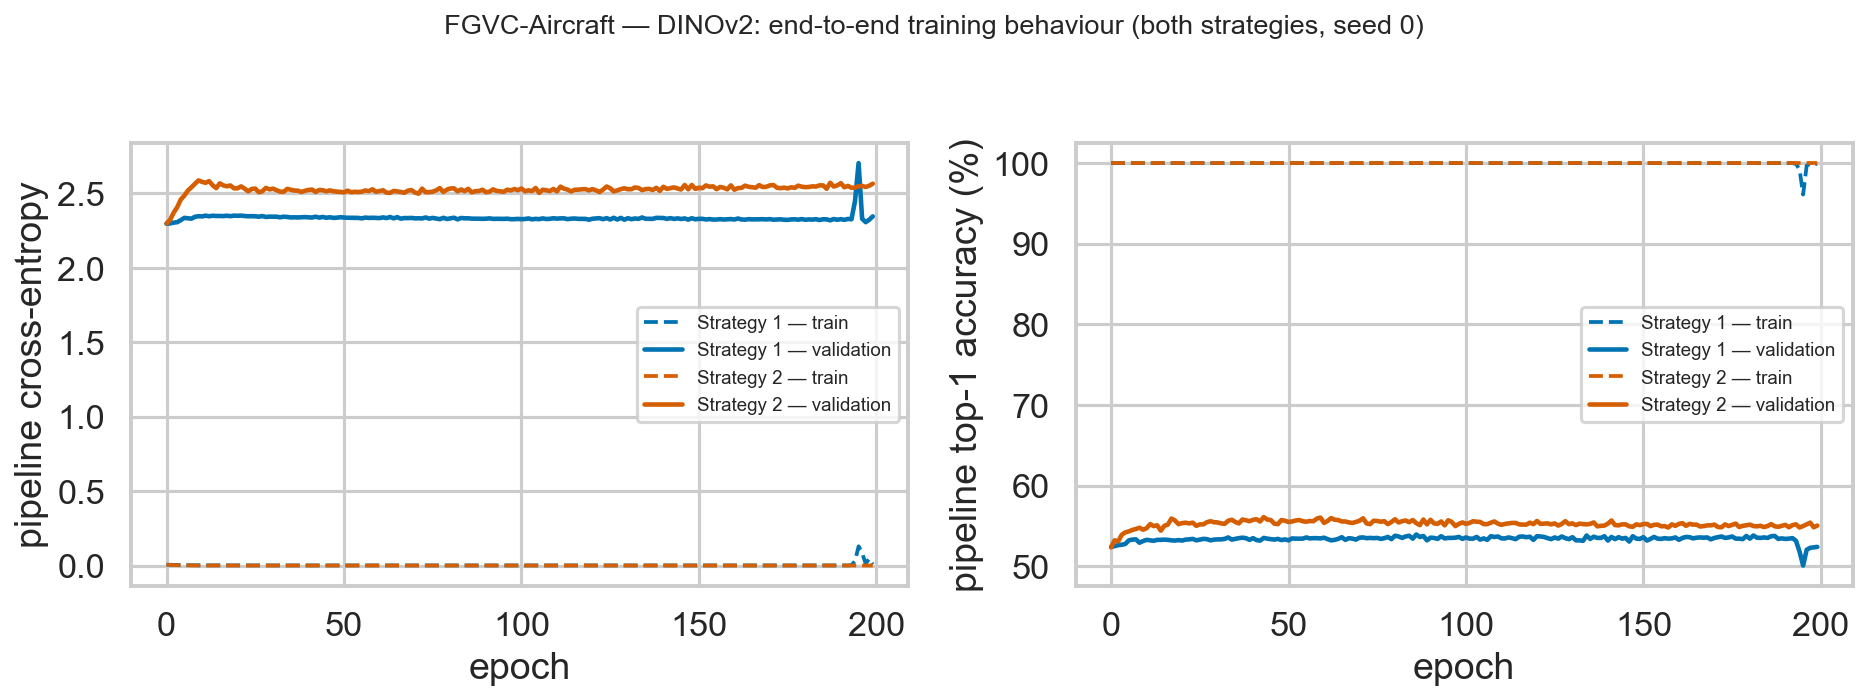

In [8]:
for ds, enc in cfg["stage3"]["settings"]:
    p = REPO / "results" / "figures" / f"stage3_curves_{ds}_{enc}.png"
    if p.exists():
        display(Image(str(p), width=980))

In [9]:
import json as _json

from src.visualize import dataset_label

HEADS = {"fm_s1": "Strategy 1", "fm_s2": "Strategy 2"}
cdir = REPO / "results" / "artifacts" / "curves_stage3"
r3 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for head in ("fm_s1", "fm_s2"):
        for seed in cfg["stage3"]["subset_seeds"]:
            h = _json.load(open(cdir / f"{ds}_{enc}_{head}_seed{seed}.json"))
            # checkpoint epoch from the table of record (runs_stage3.csv), which
            # applies the full tie-break rule (val acc -> val CE -> earliest)
            ep = int(r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                        & (r3["head"] == head)
                        & (r3["seed"] == seed)]["checkpoint_epoch"].iloc[0])
            rows.append({"dataset": dataset_label(ds), "strategy": HEADS[head],
                         "seed": seed,
                         "best val acc (%)": round(100 * max(h["val_acc"]), 2),
                         "checkpoint epoch": ep,
                         "‖ẑ−z‖ at checkpoint": round(h["mean_disp"][ep], 3)})
print("Checkpoint placement and displacement — the two mandatory strategies' "
      "final models (λ=0 and the optional-extension models are tabulated in "
      "§3.2 / §6):")
display(pd.DataFrame(rows))
failed = sorted(cdir.glob("*_failed_lv*.json"))
print(f"Failed training attempts (partial curves saved): {len(failed)}"
      + (" — " + ", ".join(p.name for p in failed) if failed else
         " — no NaN/Inf occurred; every run completed at fallback level 0 "
         "(the default recipe)."))

Checkpoint placement and displacement — the two mandatory strategies' final models (λ=0 and the optional-extension models are tabulated in §3.2 / §6):


,dataset,strategy,seed,best val acc (%),checkpoint epoch,‖ẑ−z‖ at checkpoint
0,DTD,Strategy 1,0,50.90,110,2.54
1,DTD,Strategy 1,1,54.57,79,2.55
2,DTD,Strategy 1,2,51.22,179,3.15
3,DTD,Strategy 2,0,51.97,167,2.29
4,DTD,Strategy 2,1,55.21,185,2.34
5,DTD,Strategy 2,2,52.82,175,2.28
6,FGVC-Aircraft,Strategy 1,0,53.95,86,1.19
7,FGVC-Aircraft,Strategy 1,1,52.45,117,1.14
8,FGVC-Aircraft,Strategy 1,2,50.29,36,1.24
9,FGVC-Aircraft,Strategy 2,0,56.11,43,4.69


Failed training attempts (partial curves saved): 0 — no NaN/Inf occurred; every run completed at fallback level 0 (the default recipe).


## 5 · Feature-space visualization

The spec's requirement: for a readable subset of classes, visualize the original features $z$ and the transported features $\hat{z}$ for the two Stage-3 methods, same test examples and class colours, embedding computed **jointly** over the compared sets. Below: the shared ten `viz_selection` classes per dataset (same classes, examples, and colours as Stages 1–2), one PCA fitted jointly on $[z, \hat{z}_{S1}, \hat{z}_{S2}]$ in **raw** space, validation-selected models of seed 0. As throughout the project, 2-D projections are qualitative; the purpose is to see how each training strategy changes the class structure the frozen classifier receives.

**What the panels actually show:** the first two PCs change only subtly — especially on FGVC-Aircraft, despite its +2.50-point gain. This suggests the useful movement occurs along **classifier-relevant high-dimensional directions not captured by the joint two-dimensional PCA** (which explains 15.6% of the variance on DTD and 33.0% on FGVC). That is coherent with the measured displacements (≈5–13% of the mean feature norm): small, targeted adjustments rather than a visible reorganization.

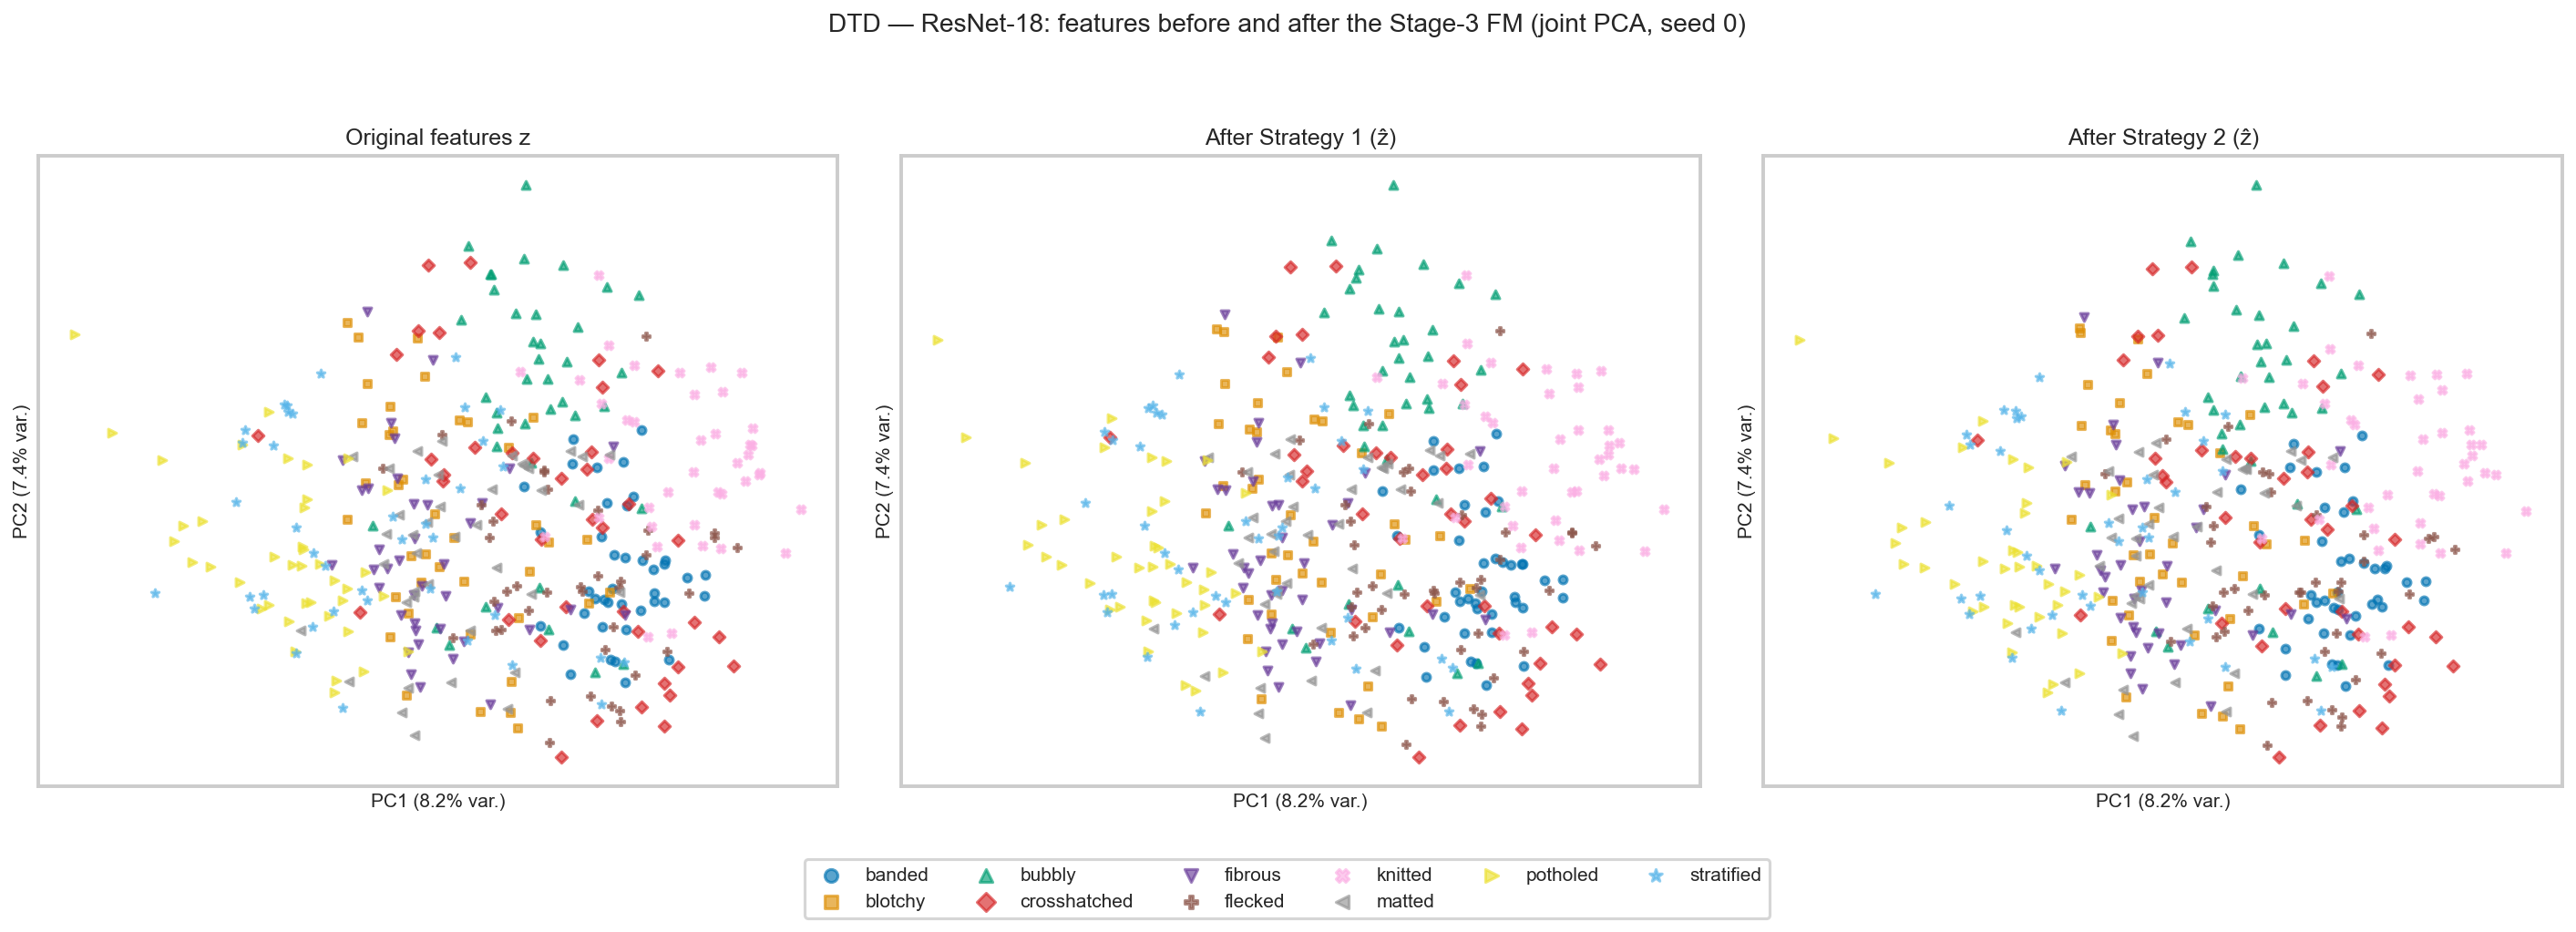

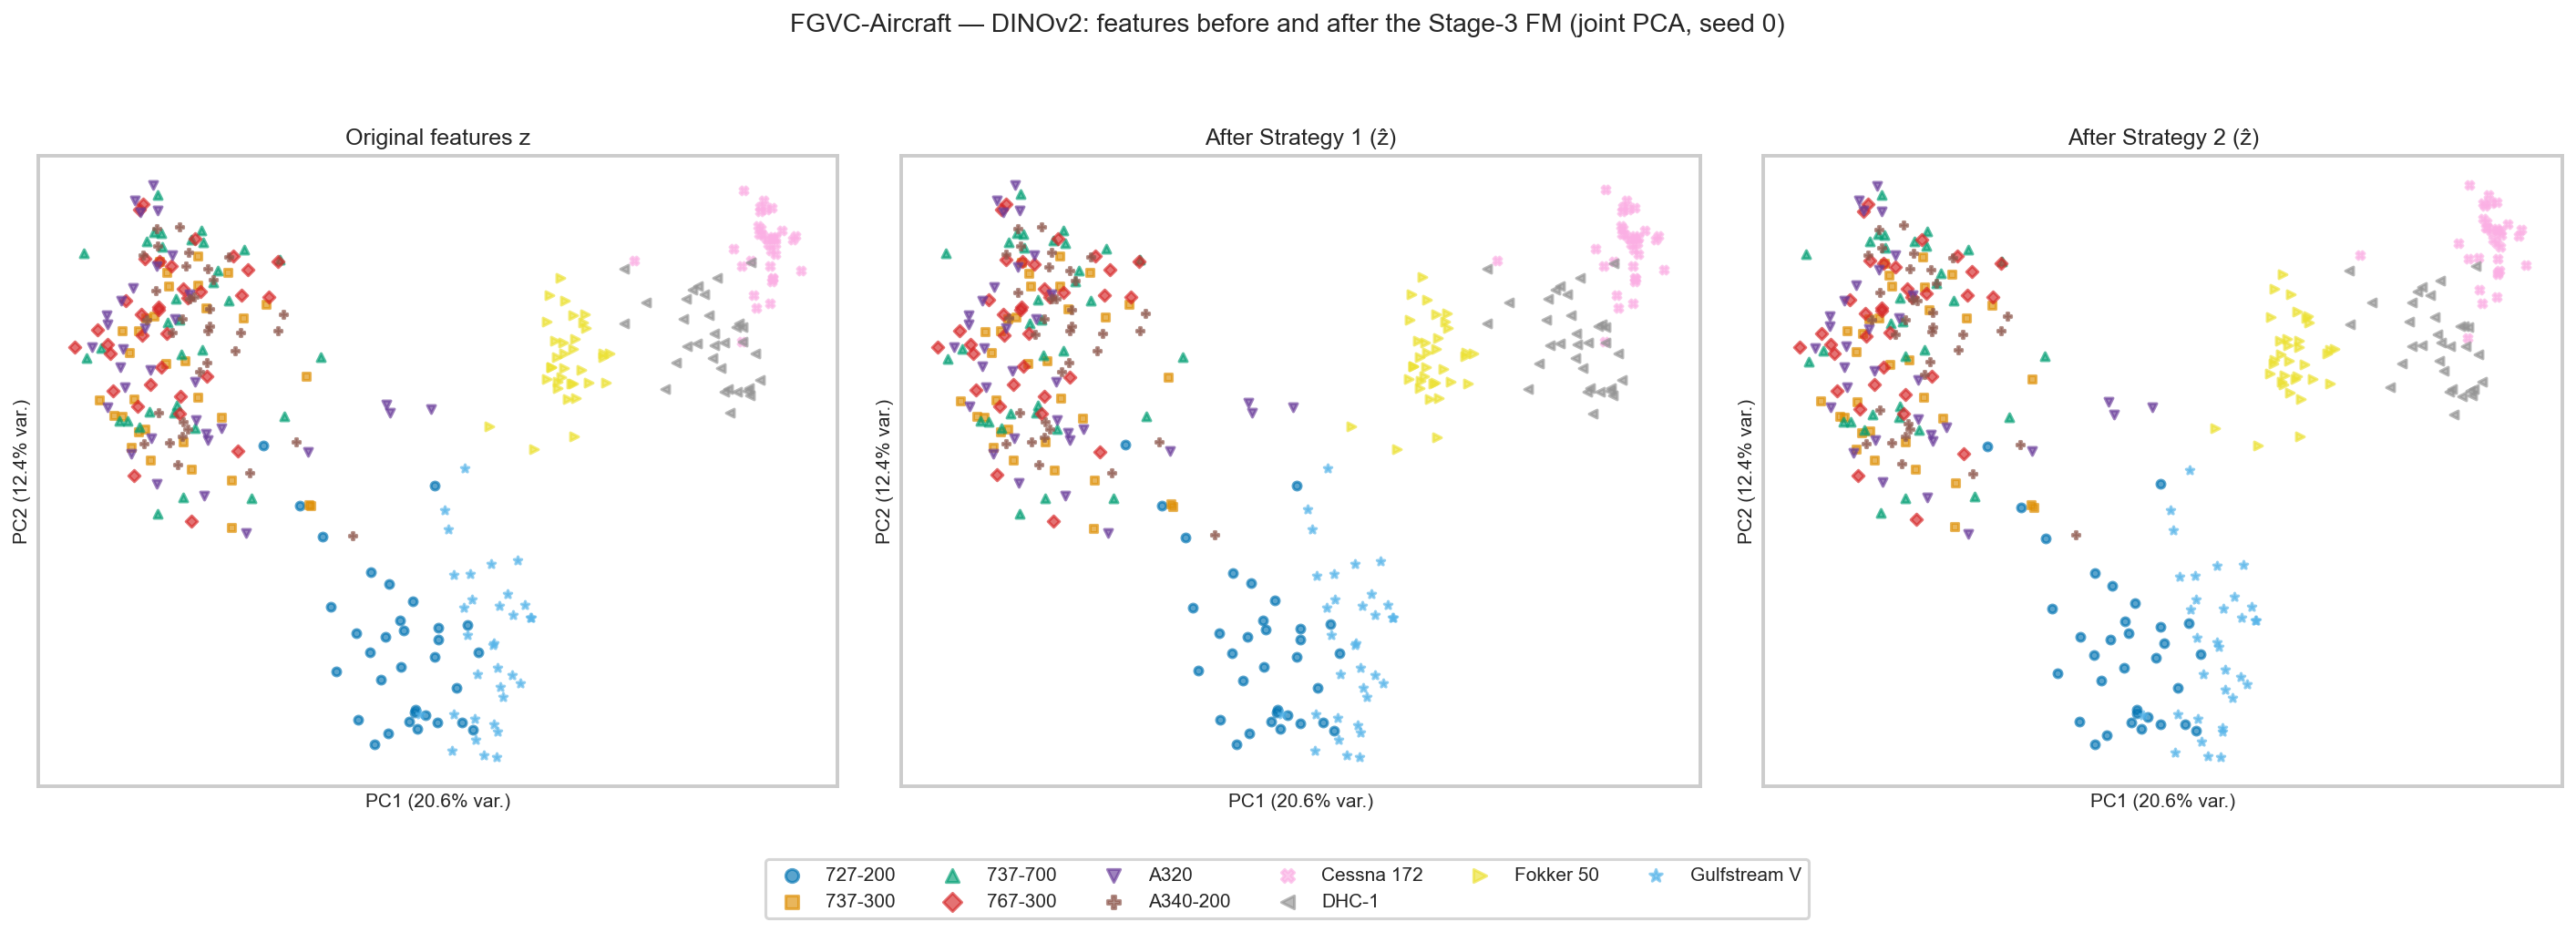

In [10]:
for ds, enc in cfg["stage3"]["settings"]:
    p = REPO / "results" / "figures" / f"stage3_features_{ds}_{enc}.png"
    if p.exists():
        display(Image(str(p), width=980))

## 6 · Discussion

Every observation below is read directly off §3–§5; the numbers appear in the generated tables and are re-derived from raw artifacts by the repro check.

**1 · The stage's question — "can FM transform frozen features into a representation the existing classifier handles better?" — gets a split answer that matches the project-wide pattern.** On **FGVC-Aircraft/DINOv2**, yes: Strategy 2 gains **+2.50 ± 0.50 points** over the pinned probe with **all three seeds agreeing** (per-seed +2.76 / +1.92 / +2.82), and Strategy 1 a smaller +0.88 ± 0.23 (3/3). On **DTD/ResNet-18**, no: every method sits within noise of the probe (S2 +0.16 ± 0.45, 2/3 seeds; S1 −0.69 ± 0.70, 1/3). This is the third stage in a row where the same geography appears — the fine-grained DINOv2 representation still holds structure a fixed linear boundary has not extracted, while DTD showed no benefit at this operating point (K = 10, this encoder, this classifier — whether its representation is exhausted in general is not established here). The gains land inside the range our pre-registered expectations called plausible ("low single digits, possibly ≈0 on DTD") — the honest headline is a *modest, consistent* improvement in one setting, not a breakthrough.

**2 · The most interesting finding: the indirect strategy beats the direct one, on both datasets.** Strategy 2 — which never lets a CE gradient touch the FM, and instead distills conservative, trust-region-bounded, CE-monotone targets through a standard velocity-regression loss — outperforms Strategy 1's direct end-to-end CE backprop everywhere (FGVC +2.50 vs +0.88; DTD +0.16 vs −0.69; and the same ordering already appeared on the validation sweeps of both datasets before any test data was seen). Why remains open: Strategy 2 differs from Strategy 1 through **several components at once** — the source-centred trust region, monotone target selection, classifier-guided target construction, and standard path-regression training — and this experiment does not isolate which is responsible. Its advantage is *consistent with* stronger regularization from bounded classifier-guided targets and path-regression training: both strategies memorize the training set (§4 — train accuracy ≈100% in both), so the difference lies in what each objective does off the training points, and everything that differs there pushes S2 toward conservatism. The resemblance to Stage 2's standard-vs-rolled-out result (path supervision generalizing where endpoint-only objectives overfit) is suggestive, but it is a pattern across experiments, not an isolated mechanism.

**3 · The displacement regularizer earns its place in Strategy 1, mildly.** The pre-registered pair puts λ = 1 above λ = 0 on both datasets (FGVC +0.88 ± 0.23 vs +0.50 ± 0.95; DTD −0.69 ± 0.70 vs −0.80 ± 0.98) — small mean differences; the three observed seeds show ≈4× lower variability with λ = 1 on FGVC (three seeds cannot establish stabilization in general). Note the geometry is not "smaller movement wins": at their selected checkpoints, S2 moves features *more* than regularized S1 on FGVC (mean ‖ẑ−z‖ ≈ 4.6 vs 1.2 units) yet generalizes better — displacement magnitude alone does not explain performance; the movement direction and/or the training construction may matter.

**4 · The protocol held up end to end.** All six probes reproduced Stage 1 — recorded validation and test accuracies within $10^{-12}$ of the published values (§2 displays the comparison; the run log additionally recorded identical best epochs); the identity guard passed at feature/logit/prediction level; no run ever hit NaN/Inf — every model trained at fallback level 0, so the entire ladder stayed unused; every comparison that actually reached test preserved its validation ordering (S2 > S1 on both datasets; λ = 1 > λ = 0 on both — non-winning S2 configurations were never test-evaluated, so nothing broader is claimed); and test was evaluated once per locked checkpoint, in one final pass per pre-registered phase (the mandatory grid; then the optional extension) — no selection depended on any test read.

### Optional extension — unfreezing the classifier, with its attribution control

Run only after the mandatory comparison was complete (ADR 0008 §9): joint FM + classifier fine-tuning (classifier lr 1e-4, FM lr 1e-3, same policy), against the **classifier-only continued-training control** — the pinned probe trained further *alone* with the same budget.

In [11]:
display(Markdown((REPO / "results" / "metrics" / "stage3_joint_table.md")
                 .read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | Joint FM + classifier fine-tuning | 53.88 ± 0.63 | -0.43 ± 0.37 |
| DTD / ResNet-18 | Control: classifier-only continued training | 54.26 ± 0.46 | -0.05 ± 0.19 |
| DTD / ResNet-18 | (reference) Strategy 2, frozen classifier | 54.47 ± 0.70 | +0.16 ± 0.45 |
| FGVC-Aircraft / DINOv2 | Joint FM + classifier fine-tuning | 51.86 ± 0.96 | +0.56 ± 0.98 |
| FGVC-Aircraft / DINOv2 | Control: classifier-only continued training | 51.94 ± 0.98 | +0.64 ± 0.08 |
| FGVC-Aircraft / DINOv2 | (reference) Strategy 2, frozen classifier | 53.80 ± 0.95 | +2.50 ± 0.50 |

Optional extension (ADR 0008 §9), run after the mandatory comparison: the classifier is unfrozen (lr 1e-4; FM lr 1e-3; same policy, 3 seeds). The **control** trains the pinned classifier further *alone* with the same budget — without it, a joint gain could not be attributed to the FM rather than to the classifier simply training longer. Same pinned-probe baselines as the main table.

**The control earns its place — and inverts the expected story.** The joint variant was pre-registered as an "upper reference"; it is not one. The joint variant does not outperform classifier-only continued training in these three seeds (FGVC: +0.56 ± 0.98 vs +0.64 ± 0.08; per-seed joint − control: +0.06 / −1.08 / +0.78; DTD: both ≈0/slightly negative), so **the results provide no evidence of an additional FM-attributable gain when the classifier is unfrozen**. The early validation-selected checkpoints (epochs 0–18, single-digit in 5 of 6 runs) are consistent with rapid overfitting in the K = 10 regime, but this experiment does not isolate classifier freezing as the cause — particularly because the best frozen configuration uses Strategy 2 while joint training uses a different objective. Even the closest matched-objective comparison (frozen Strategy 1 vs joint, both CE-trained) does not separate the two (+0.88 ± 0.23 vs +0.56 ± 0.98). **Empirically, frozen-classifier Strategy 2 remains the best tested configuration.** (Without the control, the +0.56 could have looked like a small FM win — exactly the confound the external review flagged.)

### Limitations

- **$n = 3$ subset seeds**; spreads are sample standard deviations; no significance claims. The spread measures subset-sampling variability only (probe-init and FM-init are fixed).
- **Seed 0 is partly a development run** — hyperparameters were selected on its validation split; the 3-seed mean is a summary, not an independent confirmatory estimate (pre-registered disclosure).
- **One K, one T, one encoder per dataset** — by the spec's own scoping ("to keep this stage focused"); conclusions are about this operating point.
- **The λ-ablation pair can degenerate**: where λ = 0 wins the sweep, the with/without-regularization contrast is absent from the test table by construction (stated in ADR 0008 §7).
- **2-D projections are qualitative**; the joint-PCA plane explains 15.6% (DTD) / 33.0% (FGVC) of the variance only.
- **The Strategy-2 trust region was active for nearly all targets after the early epochs** (hit rate ≈100% in the per-epoch training histories, `results/artifacts/curves_stage3/*.json`, drawn in `results/figures/stage3_diag_*.png`). Consequently, performance may depend materially on the fixed choice α = 0.1; no α ablation was performed (future work, or a clearly-labelled validation-only exploration).
- Although the linear classifier is frozen, **the FM adds nonlinear capacity** by warping feature space — $W F_\theta(z) + b$ can represent nonlinear decision boundaries even with $W, b$ fixed. The conclusions are therefore limited to the chosen FM architecture, K = 10, T = 4, and the fixed trust-region radius — not to "what a frozen classifier can do" in general.

### Deviations from, and extensions beyond, the specification

| Item | Status | Note |
|---|---|---|
| Probe trained first exactly as Stage 1, then frozen | as specified | retrained per (dataset, seed) with the Stage-1 recipe; validation audit vs `runs.csv`: 0.000 pts and exact best-epoch match on all six probes; weights pinned |
| FM close to identity | as specified (strengthened) | zero final layer ⇒ **exact** identity, asserted at feature/logit/prediction level (§2) |
| Velocity net + Euler as Stage 2; single T; K = 10 | as specified | T = 4 pre-registered (shallower backprop for Strategy 1); K = the spec's suggested default |
| Both strategies + main comparison + deliverables | as specified | table + Δ; train/val curves both methods; joint-embedding feature viz |
| Relative displacement penalty (S1); trust region, monotone acceptance, per-epoch cached targets (S2) | within spec freedom | the spec explicitly invites regularization (S1) and constrained target updates (S2); all details pre-registered in ADR 0008 |
| Validation-accuracy checkpointing | our choice (spec silent) | symmetric to how the baseline probe itself was selected; identical rule for both strategies |
| Repetition protocol (3 subset seeds) | our choice (spec silent) | keeps paired Δ ± std, consistent with Stages 1–2 |
| Optional joint fine-tuning extension + classifier-only control | done (above) | run after the mandatory comparison, exactly per ADR 0008 §9; the control shows the joint gain is fully explained by longer classifier training |

### Artifact paths

| Artifact | Path |
|---|---|
| Per-run and summary results | `results/metrics/runs_stage3.csv`, `summary_stage3.csv`, `raw/stage3_*.npy` |
| Selection transparency | `results/metrics/stage3_sweep.csv` (+ generated `stage3_*_table.md`) |
| Training histories (every model, incl. failed attempts) | `results/artifacts/curves_stage3/*.json` |
| Pinned probes + trained FM models | `results/artifacts/stage3_models/*.pt` (gitignored, regenerable via `tasks.ps1 run3`) |
| Run-0 predictions | `results/artifacts/predictions/run3_*.npz` |
| Figures | `results/figures/stage3_*.png` |

Reproduce with `tasks.ps1 run3 / tables3 / figures3 / notebook3`; `tasks.ps1 check` re-derives every summary number, every paired Δ (against the stored pinned-probe baselines), and every generated table from raw artifacts.

**Provenance.** This notebook re-executes only inside its repository (`alonengel/Computer-Vision-Project`, private — available on request); as a standalone file it is fully readable (all outputs embedded) but not re-runnable — the repo, not the notebook, is the unit of reproduction.